### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## LangChain v1 Agents: Complete Guide

## Prerequisites

Make sure you have the required packages installed and Ollama running:

```bash
pip install -U langchain langchain-community langchain-core langgraph
pip install -U ddgs python-dotenv
```

Local LLM Serving with Ollama:
```bash
ollama pull qwen3
ollama pull gemma3
```

In [ ]:
# pip install -U langchain langchain-community langchain-core langgraph
# pip install -U ddgs python-dotenv

---
## 1. Agent with Explicit Model Instance

Full control over model configuration by creating an explicit ChatOllama instance.

## Model Parameters Explained
- **temperature**: Controls randomness (0.0 = deterministic, 1.0 = very creative)
- **num_predict**: Maximum tokens to generate (similar to max_tokens in OpenAI)
- **top_k**: Number of highest probability tokens to consider
- **top_p**: Cumulative probability threshold for token selection
- **repeat_penalty**: Penalty for repeating tokens
- **num_ctx**: Context window size

In [4]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
from langfuse.langchain import CallbackHandler
import tools

langfuce_trace = CallbackHandler()

In [5]:
system_prompt = """You are a helpful AI assistant. 
Use the available tools when needed to answer questions accurately.
If you need to search for information, use the web_search tool.
Always provide clear and concise answers.
"""

In [7]:
print(tools.web_search.invoke({"query": "What is Langchain?", "num_results": 1}))
# print(tools.web_search.invoke({"query": "Python programming", "num_results": 1}))

Search Results for 'What is Langchain?':


1. **Langchain**
   8 hours ago - This post goes into the technical details of how we built it: why we built Engine, what inputs and outputs it works with, and the architecture decisions that let it analyze large volumes of traces. LangSmith is the home of the agent improvement loop.
   https://www.langchain.com/blog/how-we-built-langsmith-engine-our-agent-for-improving-agents


### Your First Agent

In [8]:
model = ChatOllama(model="qwen3", base_url="http://localhost:11434")

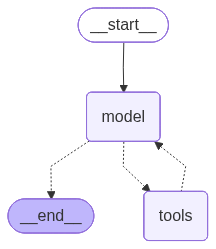

In [9]:
agent = create_agent(model=model, tools=[tools.web_search], system_prompt=system_prompt)
agent

In [10]:
result = agent.invoke({"messages": "What is the top 10 global news right now?"}, config={"callbacks": [langfuce_trace]})

In [ ]:
result

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='a27c07e5-c441-4a61-befa-ba032252c700'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-05-29T07:09:19.418247099Z', 'done': True, 'done_reason': 'stop', 'total_duration': 63841665431, 'load_duration': 17435799961, 'prompt_eval_count': 233, 'prompt_eval_duration': 12075151074, 'eval_count': 173, 'eval_duration': 34168940410, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e728f-ed56-7f13-89f2-3c383e57a4b4-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news', 'num_results': 10}, 'id': '36792d79-6834-4b63-9c72-3c3797e215ec', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 173, 'total_tokens': 406}),
  ToolMessage(content="Search Results for 'top 10 global news':\n\n\n1. **Reuters World News | Late

In [15]:
print(result['messages'])

[HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='a27c07e5-c441-4a61-befa-ba032252c700'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-05-29T07:09:19.418247099Z', 'done': True, 'done_reason': 'stop', 'total_duration': 63841665431, 'load_duration': 17435799961, 'prompt_eval_count': 233, 'prompt_eval_duration': 12075151074, 'eval_count': 173, 'eval_duration': 34168940410, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e728f-ed56-7f13-89f2-3c383e57a4b4-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news', 'num_results': 10}, 'id': '36792d79-6834-4b63-9c72-3c3797e215ec', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 173, 'total_tokens': 406}), ToolMessage(content="Search Results for 'top 10 global news':\n\n\n1. **Reuters World News | Latest Top Stories | 

In [20]:
print(result['messages'][-1].content) # Access result from AIMessage class output

Here are the top global news stories based on recent updates from credible news outlets:

1. **Global Temperature Projections**: A 75% chance the average global temperature between 2026-2030 will exceed the agreed-upon climate limit (NBC News).  
2. **Hong Kong's Airport Expansion**: Hong Kong unveils a revamped Terminal 2 amid ongoing airport disputes (CNN).  
3. **French Pastries Trend**: 10 new French pastries gaining popularity in global culinary circles (CNN).  
4. **Italian Court Ruling**: A top Italian court rules hotels can legally refuse tap water to guests (CNN).  
5. **Toronto's Kung Fu Legacy**: Celebrating 65 years of Canada's oldest martial arts school (Global News).  
6. **Middle East Conflicts**: Ongoing tensions and regional developments in the Middle East (ABC News).  
7. **Asia's Airport Wars**: Escalating competition among Asian airports, including Hong Kong's plans (CNN).  
8. **Climate Action Updates**: Latest developments in global efforts to combat climate chang

In [21]:

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here are the top global news stories based on recent updates from credible news outlets:

1. **Global Temperature Projections**: A 75% chance the average global temperature between 2026-2030 will exceed the agreed-upon climate limit (NBC News).  
2. **Hong Kong's Airport Expansion**: Hong Kong unveils a revamped Terminal 2 amid ongoing airport disputes (CNN).  
3. **French Pastries Trend**: 10 new French pastries gaining popularity in global culinary circles (CNN).  
4. **Italian Court Ruling**: A top Italian court rules hotels can legally refuse tap water to guests (CNN).  
5. **Toronto's Kung Fu Legacy**: Celebrating 65 years of Canada's oldest martial arts school (Global News).  
6. **Middle East Conflicts**: Ongoing tensions and regional developments in the Middle East (ABC News).  
7. **Asia's Airport Wars**: Escalating competition among Asian airports, including Hong Kong's plans (CNN).  
8. **Clima

In [22]:
result1 = agent.invoke(result, config={"callbacks": [langfuce_trace]})

In [23]:
result1

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='a27c07e5-c441-4a61-befa-ba032252c700'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2026-05-29T07:09:19.418247099Z', 'done': True, 'done_reason': 'stop', 'total_duration': 63841665431, 'load_duration': 17435799961, 'prompt_eval_count': 233, 'prompt_eval_duration': 12075151074, 'eval_count': 173, 'eval_duration': 34168940410, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019e728f-ed56-7f13-89f2-3c383e57a4b4-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news', 'num_results': 10}, 'id': '36792d79-6834-4b63-9c72-3c3797e215ec', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 233, 'output_tokens': 173, 'total_tokens': 406}),
  ToolMessage(content="Search Results for 'top 10 global news':\n\n\n1. **Reuters World News | Late

### Experimenting with Different Settings

Let's compare different model configurations to see how they affect the output:

In [28]:
question = "What is the capital of France? Provide a brief explanation."

model1 = ChatOllama(model="qwen3", base_url="http://localhost:11434",
                    temperature=0,
                    top_p=1,
                    repeart_penalty=1.2,
                    num_predict=1000,
                    num_ctx=4096,
                    reasoning=True)

agent1 = create_agent(model=model1, tools=[tools.web_search], system_prompt=system_prompt)
result1 = agent1.invoke({"messages": question}, config={"callbacks": [langfuce_trace]})

In [29]:
result1

{'messages': [HumanMessage(content='What is the capital of France? Provide a brief explanation.', additional_kwargs={}, response_metadata={}, id='8f77c5f2-2ced-4b03-9382-575f51eac82b'),
  AIMessage(content='The capital of France is **Paris**. Paris is not only the political and cultural center of France but also its largest city. It serves as the seat of the French government, home to important institutions like the Élysée Palace and the French Senate. Known for landmarks such as the Eiffel Tower, Louvre Museum, and Notre-Dame Cathedral, Paris is a global hub for art, fashion, and commerce. \n\n', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the capital of France and a brief explanation. Let me start by recalling what I know. France is a country in Europe, and I believe the capital is Paris. But wait, I should make sure this information is up-to-date. Maybe there\'s a possibility of a change, though it\'s unlikely. To confirm, I can use the web_search tool prov

## 2. Dynamic Model Selection (Qwen3 → Gemma3)

Cost-optimization strategy where the agent automatically switches between models based on conversation complexity.

## Selection Logic
- **< 10 messages**: Use Qwen3 (fast, efficient)
- **≥ 10 messages**: Use Gemma3 (better reasoning, longer context)

## Real-World Applications
- Customer service bots (simple queries → Qwen3, complex issues → Gemma3)
- Research assistants (quick facts → Qwen3, analysis → Gemma3)

In [30]:
# Import required modules
from langchain_ollama import ChatOllama
from langchain.agents import create_agent, AgentState
from langgraph.runtime import Runtime
import tools

# Import the middleware decorator
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse


In [ ]:
basic_model = ChatOllama(model="qwen3", base_url="http://localhost:11434", num_predict=1000)
advanced_model = ChatOllama(model="llama3.2", base_url="http://localhost:11434", num_predict=1000)

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    message_count = len(request.state["messages"])
    if message_count<3:
        print(f"Using Qwen3 for {message_count} messages")
        request.model = basic_model
    else:
        print(f"Using llama3.2 for {message_count} messages")
        request.model = advanced_model

    return handler(request)

In [39]:
agent = create_agent(model=basic_model,
                     tools = [tools.web_search],
                     system_prompt=system_prompt,
                     middleware=[dynamic_model_selection])

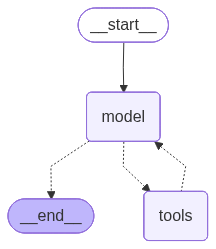

In [33]:
agent

In [40]:
def get_agent_output(messages:list):
    messages = {'messages': messages} # dict

    result = agent.invoke(messages, config={"callbacks": [langfuce_trace]})

    return result

In [46]:
messages = ["How are you?", "What's the weather in Mumbai today?,", "Explain machine learning"]
# result = get_agent_output(messages)

In [42]:
result


{'messages': [HumanMessage(content='How are you?', additional_kwargs={}, response_metadata={}, id='c83f84aa-4806-4783-9fc2-49d6ae2304be'),
  HumanMessage(content="What's the weather in Mumbai today?,", additional_kwargs={}, response_metadata={}, id='e8b14757-dcab-4446-b049-c4611bfdcf65'),
  HumanMessage(content='Explain machine learning', additional_kwargs={}, response_metadata={}, id='e0b554f2-7722-4e77-ae62-d618748d23ae'),
  HumanMessage(content='What about deep learning?', additional_kwargs={}, response_metadata={}, id='4fe8d630-6163-4ec9-8a25-77cadad0bac0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T08:38:38.52468471Z', 'done': True, 'done_reason': 'stop', 'total_duration': 39535061154, 'load_duration': 29001185577, 'prompt_eval_count': 255, 'prompt_eval_duration': 4689001854, 'eval_count': 65, 'eval_duration': 5749513172, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e72

### Streaming Agent Responses
#### Stream Modes
- "values": Get complete state at each step
- "updates": Get only the changes/updates
- "messages": Get only message updates

In [47]:
messages

['How are you?',
 "What's the weather in Mumbai today?,",
 'Explain machine learning']

In [48]:
for chunk in agent.stream({"messages": messages}, stream_mode="values"):
    print(chunk['messages'][-1].content, end='', flush=True)

    print("\n\n------")

Explain machine learning

------
REQUEST:  {'model': ChatOllama(output_version=None, model='qwen3', num_predict=1000, base_url='http://localhost:11434'), 'messages': [HumanMessage(content='How are you?', additional_kwargs={}, response_metadata={}, id='33a1031f-0eaa-4967-bae3-22c4ce9e5807'), HumanMessage(content="What's the weather in Mumbai today?,", additional_kwargs={}, response_metadata={}, id='2633ca96-5b94-4a23-949e-794c48ab81d8'), HumanMessage(content='Explain machine learning', additional_kwargs={}, response_metadata={}, id='d2b54e90-77ff-49db-8031-c74753c897b5')], 'system_message': SystemMessage(content='You are a helpful AI assistant. \nUse the available tools when needed to answer questions accurately.\nIf you need to search for information, use the web_search tool.\nAlways provide clear and concise answers.\n', additional_kwargs={}, response_metadata={}), 'tool_choice': None, 'tools': [StructuredTool(name='web_search', description='Search the web using DuckDuckGo.\n\n    Arg

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_12752\2647143100.py:13: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


}

{
  "name": "web_search",
  "parameters": {
    "query": "machine learning explanation",
    "num_results": 10
  }
}

------
Search Results for 'Mumbai weather today':


1. **Mumbai Weather Today, Mumbai Temperature Hourly and Weekly Forecast | The Times of India**
   1 day ago - Today's Weather in Mumbai: In Mumbai today, the weather is expected to be Overcast with a maximum temperature of 31.8°C and a minimum of 29.2°C. Sunrise in Mumbai is set for 06:00 AM and sunset at 07:10 PM Atmospheric pressure will be around ...
   https://timesofindia.indiatimes.com/weather/mumbai-weather-forecast-today/3258

------
REQUEST:  {'model': ChatOllama(output_version=None, model='qwen3', num_predict=1000, base_url='http://localhost:11434'), 'messages': [HumanMessage(content='How are you?', additional_kwargs={}, response_metadata={}, id='33a1031f-0eaa-4967-bae3-22c4ce9e5807'), HumanMessage(content="What's the weather in Mumbai today?,", additional_kwargs={}, response_metadata={}, id='2633ca96-5b9

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_12752\2647143100.py:13: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


The current weather in Mumbai today is expected to be overcast with a maximum temperature of 31.8°C and a minimum of 29.2°C.

Now, let me explain machine learning:

**What is Machine Learning?**

Machine learning (ML) is a subset of artificial intelligence (AI) that involves training algorithms to make predictions or decisions based on data without being explicitly programmed.

**How does Machine Learning work?**

The process of machine learning typically involves the following steps:

1. **Data Collection**: Gathering a large dataset relevant to the problem you want to solve.
2. **Data Preprocessing**: Cleaning, transforming, and preparing the data for use in the algorithm.
3. **Model Training**: Feeding the preprocessed data into an algorithm, which adjusts its parameters to minimize error and improve performance.
4. **Model Evaluation**: Testing the trained model on new, unseen data to evaluate its accuracy and performance.
5. **Deployment**: Integrating the trained model into a lar

In [50]:
for chunk in agent.stream(
    {"messages": messages},
    config={"callbacks": [langfuce_trace]},
    stream_mode="updates",
):
    # print(chunk, end='', flush=True)
    if 'model' in chunk:
        chunk['model']['messages'][-1].pretty_print()
    if 'tools' in chunk:
        chunk['tools']['messages'][-1].pretty_print()
    else:
        print(chunk)
    print("\n\n------")

REQUEST:  {'model': ChatOllama(output_version=None, model='qwen3', num_predict=1000, base_url='http://localhost:11434'), 'messages': [HumanMessage(content='How are you?', additional_kwargs={}, response_metadata={}, id='261224cd-126a-4960-b35a-2a7ccd2e869b'), HumanMessage(content="What's the weather in Mumbai today?,", additional_kwargs={}, response_metadata={}, id='d9cad47b-4832-4aad-9924-1300ee6e6715'), HumanMessage(content='Explain machine learning', additional_kwargs={}, response_metadata={}, id='a3038d4b-8ca6-4504-a114-31056187601a')], 'system_message': SystemMessage(content='You are a helpful AI assistant. \nUse the available tools when needed to answer questions accurately.\nIf you need to search for information, use the web_search tool.\nAlways provide clear and concise answers.\n', additional_kwargs={}, response_metadata={}), 'tool_choice': None, 'tools': [StructuredTool(name='web_search', description='Search the web using DuckDuckGo.\n\n    Args:\n        query: Search query s

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_12752\2647143100.py:13: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


================================== Ai Message ==================================
Tool Calls:
  web_search (a47d4042-1024-44bb-ade0-95025b6ecb00)
 Call ID: a47d4042-1024-44bb-ade0-95025b6ecb00
  Args:
    query: Mumbai weather today
    num_results: 10
  web_search (880d9628-3736-4386-b686-ccec19926d3f)
 Call ID: 880d9628-3736-4386-b686-ccec19926d3f
  Args:
    query: machine learning explanation
    num_results: 10
  web_search (904a4cca-5378-4ecf-a3b0-9e6c6722ad7f)
 Call ID: 904a4cca-5378-4ecf-a3b0-9e6c6722ad7f
  Args:
    num_results: 10
    query: What is the weather like in Mumbai today?
{'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T08:59:04.493075088Z', 'done': True, 'done_reason': 'stop', 'total_duration': 40808836882, 'load_duration': 29225594285, 'prompt_eval_count': 249, 'prompt_eval_duration': 4562656700, 'eval_count': 84, 'eval_duration': 6899596556, 'logprobs': None, 'model_name': 'llama

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_12752\2647143100.py:13: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


================================== Ai Message ==================================

Here are the answers to your questions:

**How are you?**

I'm doing well, thank you for asking! I'm a helpful AI assistant, and I'm here to provide information and answer your questions to the best of my abilities.

**What's the weather like in Mumbai today?**

According to the latest weather updates, it is expected to be overcast with a maximum temperature of 31.8°C and a minimum of 29.2°C in Mumbai today. There is also a possibility of light rain or thundershowers towards the evening or night.

**Explain machine learning**

Machine learning is a branch of artificial intelligence that involves training algorithms to learn from data and make predictions or decisions without being explicitly programmed to do so. It's a type of AI where systems improve their performance over time based on the data they receive, allowing them to identify patterns and make informed decisions. Machine learning can be used in 